# L3 —— 基质细胞 细胞类型确认

In [1]:
import os, re
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
from scipy.sparse import issparse
import matplotlib.pyplot as plt
import omicverse as ov

# 路径与文件
DATA_ROOT = "/mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data"
ANNO_DIR  = os.path.join(DATA_ROOT, "06_annotation/L3/stromal"); os.makedirs(ANNO_DIR, exist_ok=True)
FIG_DIR   = os.path.join(ANNO_DIR, "figs");          os.makedirs(FIG_DIR,  exist_ok=True)
IN_PATH   = os.path.join(DATA_ROOT, "06_annotation/L2/L2_stromal_annotated.h5ad")
OUT_H5AD  = os.path.join(ANNO_DIR, "L3_stromal_annotated.h5ad")
OUT_CSV   = os.path.join(ANNO_DIR, "L3_stromal_summary.csv")

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## 数据读取

In [2]:
adata = sc.read_h5ad(IN_PATH)
adata

AnnData object with n_obs × n_vars = 114604 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'L1lin_conf', 'leiden_0.4', 'L2_marker', 'L2_score', 'L2_gpt', 'L2_celltype_sub', 'L2_celltype', 'L2_conf_methods', 'L2_stability', 'L2_conf', 'L2_votes'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'GSE_colors', 'L1_lineage_colors', 'L2_celltype_colors', 'REFERENCE_MANU', 'hvg', 'leiden_0.2', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.6', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [3]:
adata.obs.head()

,GSM,GSE,group,leiden_scVI_0.2,L1_lineage,L1lin_conf,leiden_0.4,L2_marker,L2_score,L2_gpt,L2_celltype_sub,L2_celltype,L2_conf_methods,L2_stability,L2_conf,L2_votes
GSM8980878_UC68_CELL6_N4,GSM8980878,GSE296969,UC,1,Stromal,1.0,8,Other,Other,Other,Other,Stromal|Other,0.000000,0.333333,0.066667,L2_marker+L2_score+L2_gpt
GSM8980878_UC68_CELL14_N2,GSM8980878,GSE296969,UC,1,Stromal,1.0,2,Fibroblast,Fibroblast,Fibroblast,Fibroblast,Stromal|Fibroblast,1.000000,0.999955,0.999991,L2_marker+L2_score+L2_gpt
GSM8980878_UC68_CELL20_N5,GSM8980878,GSE296969,UC,5,Stromal,1.0,6,Fibroblast,Fibroblast,Pericyte_SMC,Fibroblast,Stromal|Fibroblast,0.666667,0.997566,0.732847,L2_marker+L2_score+L2_gpt
GSM8980878_UC68_CELL21_N3,GSM8980878,GSE296969,UC,1,Stromal,1.0,6,Fibroblast,Fibroblast,Pericyte_SMC,Fibroblast,Stromal|Fibroblast,0.666667,0.997566,0.732847,L2_marker+L2_score+L2_gpt
GSM8980878_UC68_CELL26_N2,GSM8980878,GSE296969,UC,5,Stromal,1.0,3,Fibroblast,Other,Pericyte_SMC,Other,Stromal|Other,0.500000,0.333333,0.466667,L2_marker+L2_score+L2_gpt


精简一下基质细胞adata

In [4]:
obs_keep_candidates = [
    # 批次 & 来源
    "GSM", "GSE", "group",
    # L1 关键信息
    "leiden_scVI_0.2",
    "L1_lineage",
    "leiden_0.4",
    # L2 最终结果
    "L2_celltype_sub",        # 无前缀的子类
]
# 只保留实际存在的列
obs_keep = [c for c in obs_keep_candidates if c in adata.obs.columns]
adata.obs = adata.obs[obs_keep]
adata

AnnData object with n_obs × n_vars = 114604 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'GSE_colors', 'L1_lineage_colors', 'L2_celltype_colors', 'REFERENCE_MANU', 'hvg', 'leiden_0.2', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.6', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

## 查看L2注释结果

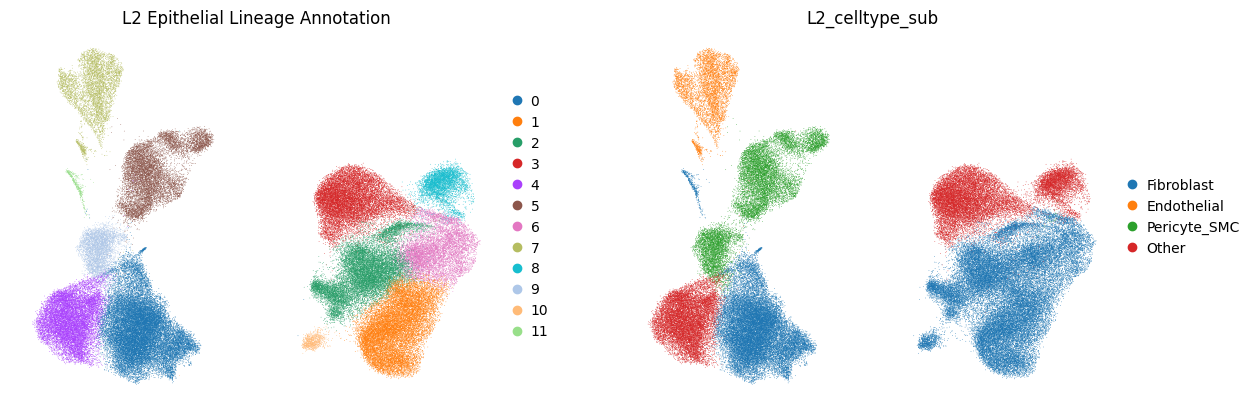

In [5]:
sc.pl.umap(adata,
           color=["leiden_0.4","L2_celltype_sub"],
           frameon=False,
           title="L2 Epithelial Lineage Annotation",  # 英文标题
)

### 成纤维细胞

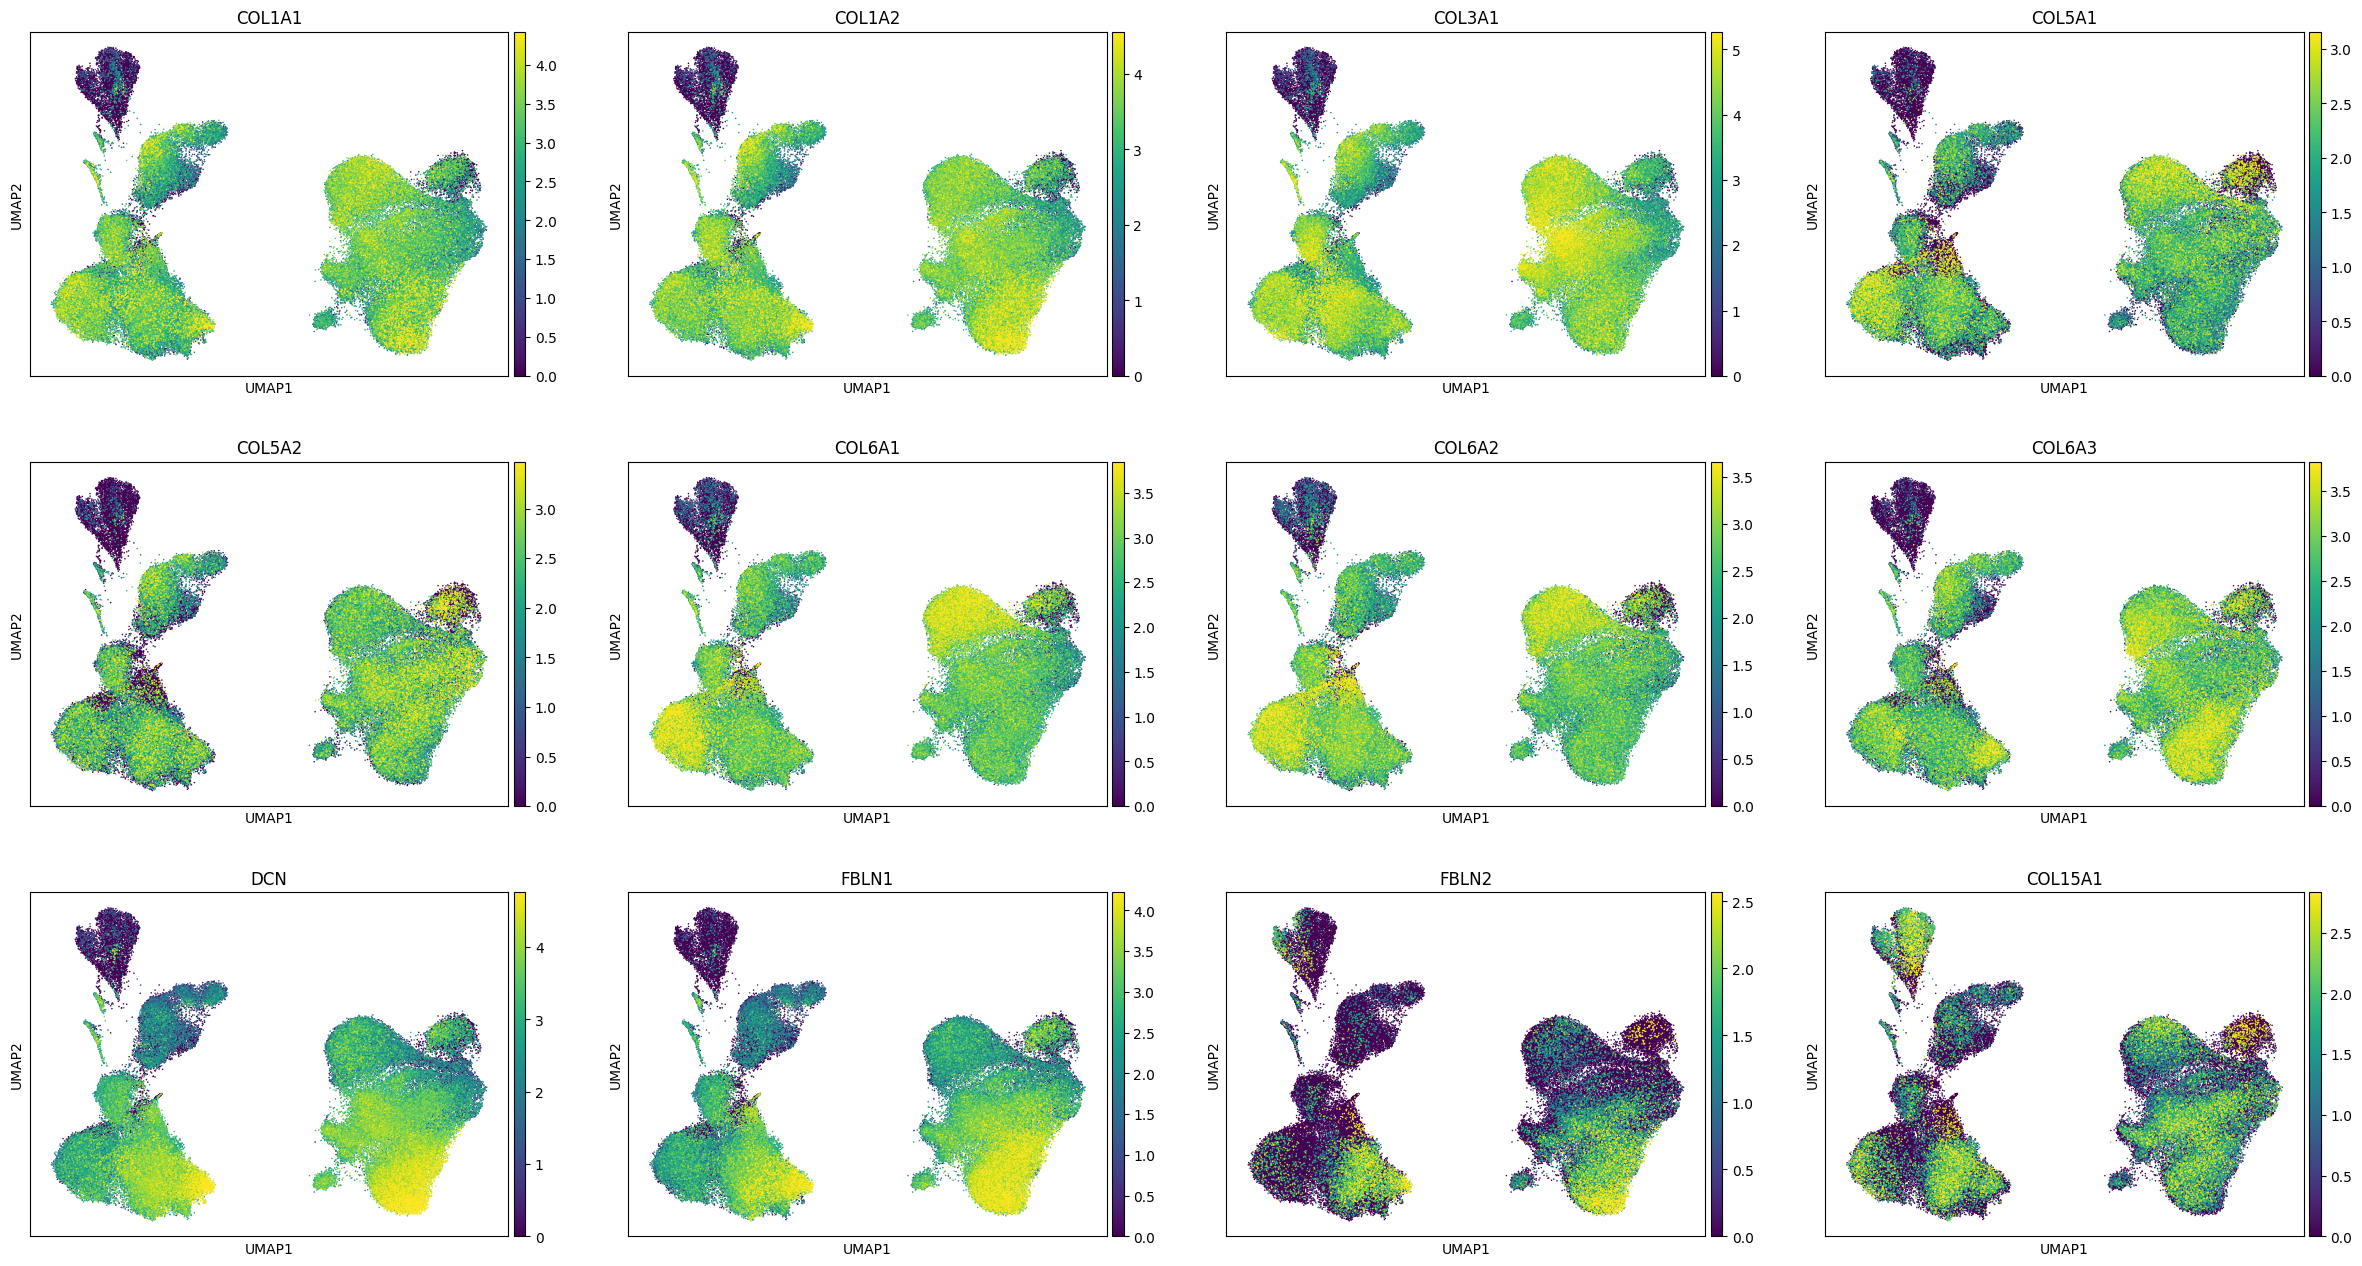

In [6]:
fibro_markers = [
    "COL1A1", "COL1A2", "COL3A1", "COL5A1", "COL5A2", "COL6A1", "COL6A2", "COL6A3", # 核心 ECM
    "DCN", "FBLN1", "FBLN2", # 基质核心蛋白
    "COL15A1" # 结肠 / 黏膜固有层特异性的 fibroblast marker
]
def safe_genes(genes, adata):
    return [g for g in genes if g in adata.var_names]

sc.pl.umap(adata, color=safe_genes(fibro_markers, adata), ncols=4, cmap="viridis", vmax="p99", vmin=0, size=5,)

炎症 fibroblast

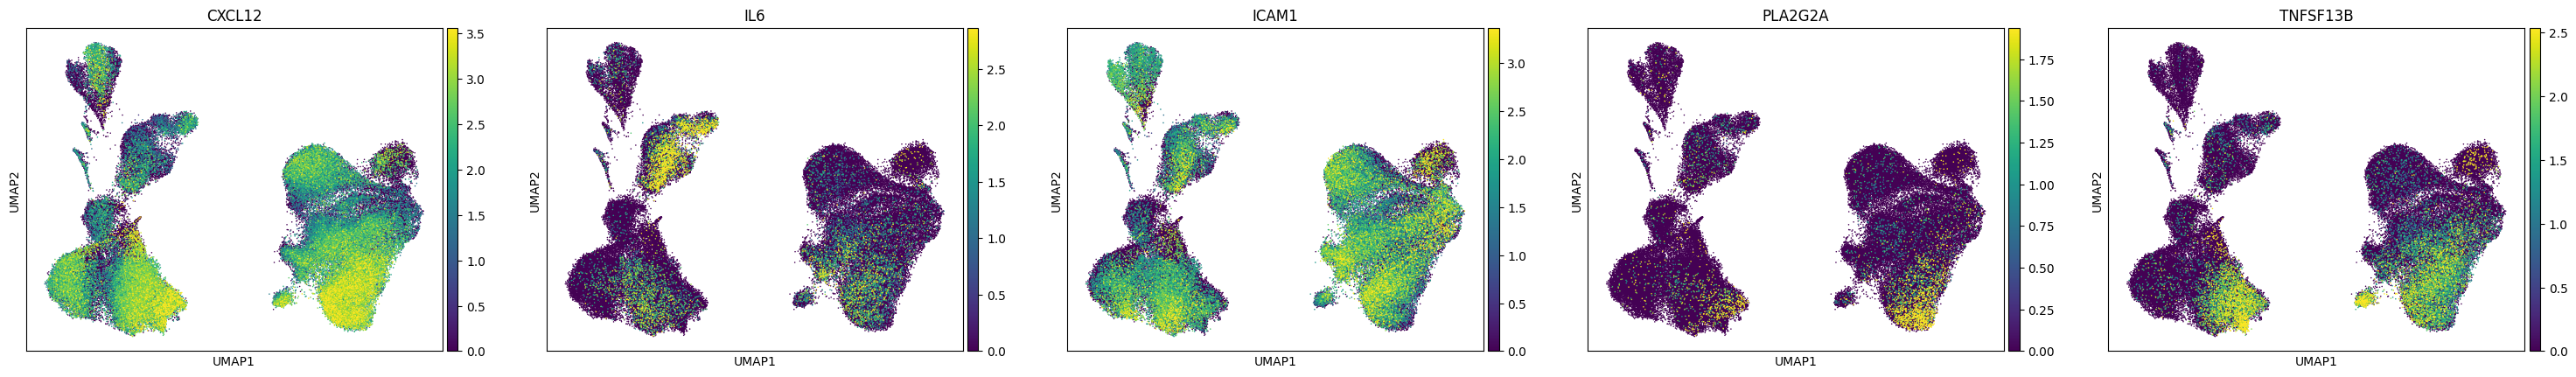

In [7]:
fibro_inflammatory = [
    "CXCL12", "IL6", "ICAM1", "PLA2G2A", "TNFSF13B"
]
sc.pl.umap(adata, color=safe_genes(fibro_inflammatory, adata), ncols=5, cmap="viridis", vmax="p99", vmin=0, size=5,)

### 内皮细胞

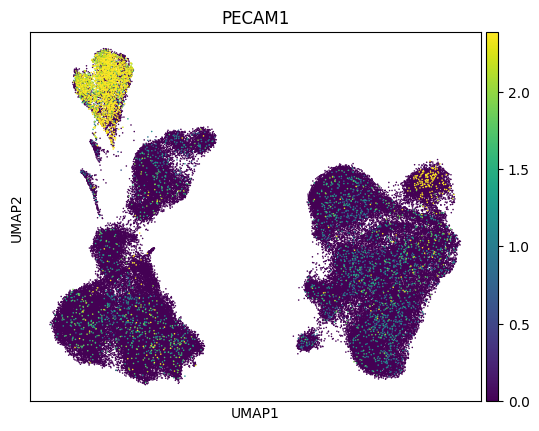

In [8]:
endo_markers = [
    "PECAM1", "VWF", "KDR", "CD34", "CLDN5", "EMCN"
]
sc.pl.umap(adata, color=safe_genes(endo_markers, adata), ncols=2, cmap="viridis", vmax="p99", vmin=0, size=5,)

内皮细胞完全没有问题

### Pericyte

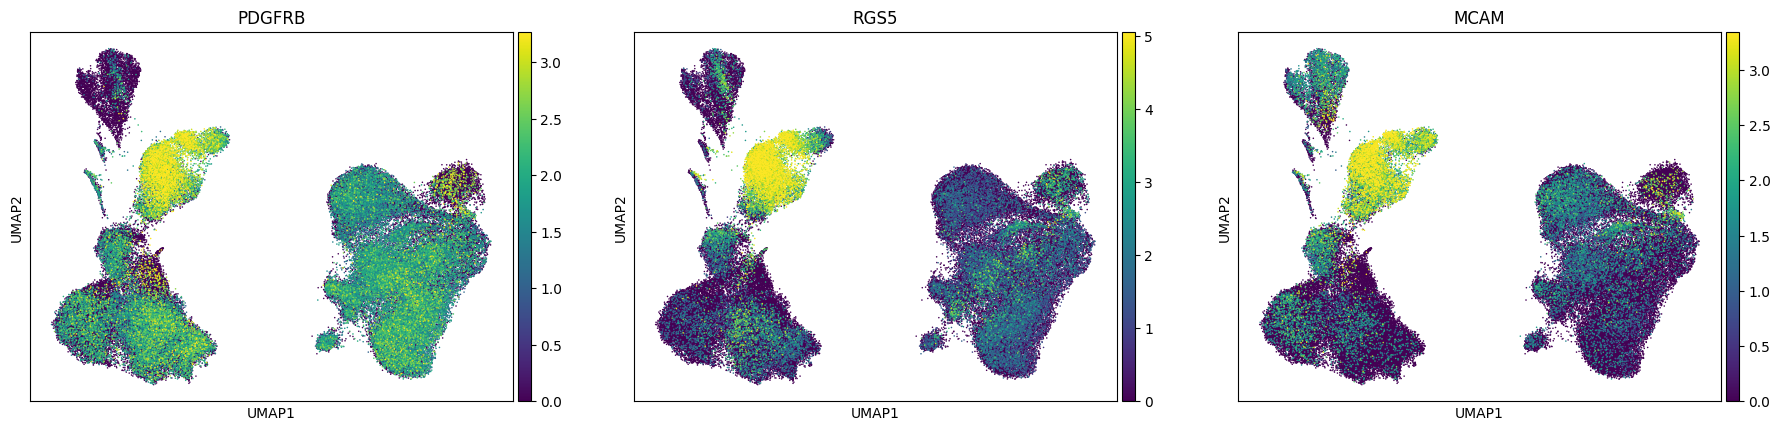

In [9]:
pericyte_markers = [
    "PDGFRB", # 周细胞最经典受体
    "RGS5", # 极强的 pericyte marker
    "MCAM", # CD146, 周细胞标志物
]
sc.pl.umap(adata, color=safe_genes(pericyte_markers, adata), ncols=3, cmap="viridis", vmax="p99", vmin=0, size=5,)

第5群细胞是标准的周细胞，L2当中注释正确

### 平滑肌细胞

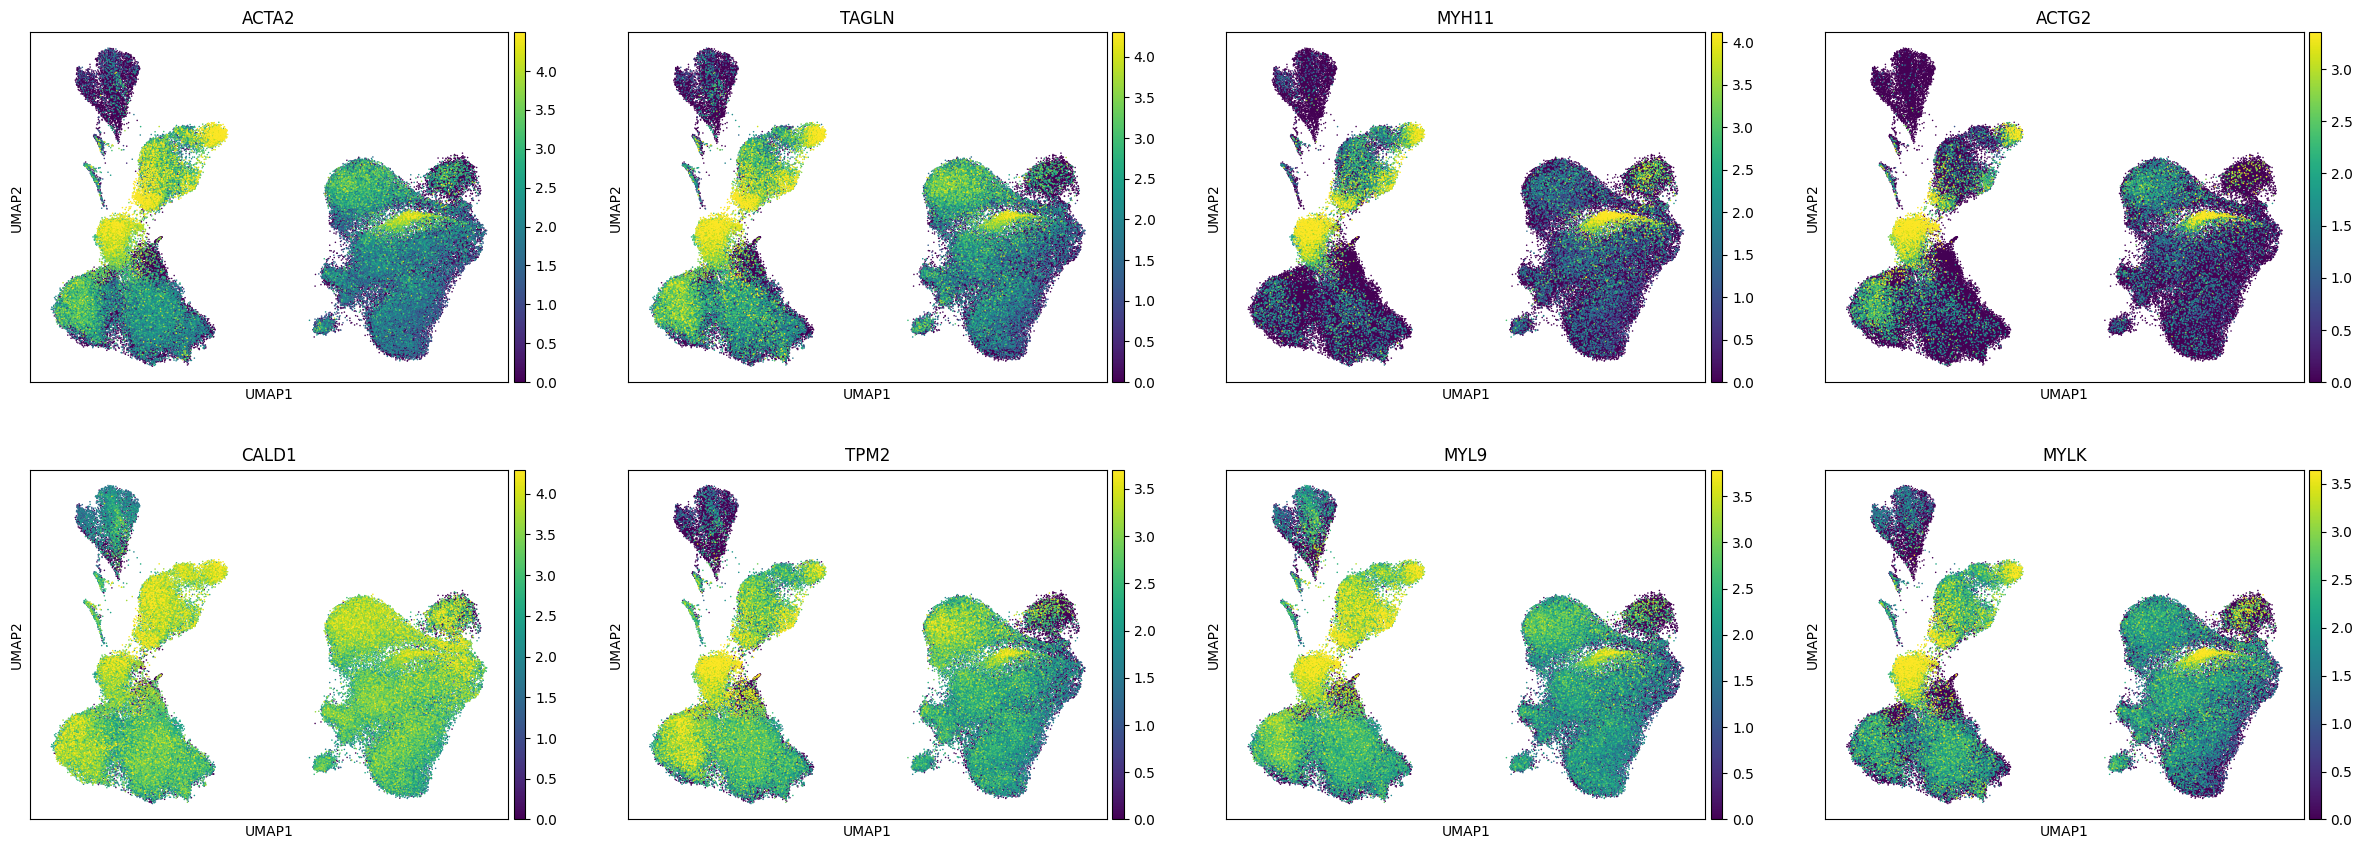

In [10]:
smc_markers = [
    "ACTA2",
    "TAGLN",
    "MYH11",
    "ACTG2",
    "CALD1",
    "TPM2",
    "MYL9", "MYLK"
]
sc.pl.umap(adata, color=safe_genes(smc_markers, adata), ncols=4, cmap="viridis", vmax="p99", vmin=0, size=5,)

### Other 为成纤维细胞

In [11]:
adata

AnnData object with n_obs × n_vars = 114604 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'GSE_colors', 'L1_lineage_colors', 'L2_celltype_colors', 'REFERENCE_MANU', 'hvg', 'leiden_0.2', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.6', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap', 'L2_celltype_sub_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [12]:
adata.obs["L2_celltype_sub"].value_counts()

L2_celltype_sub
Fibroblast      64989
Other           30490
Pericyte_SMC    13870
Endothelial      5255
Name: count, dtype: int64

In [13]:
import pandas as pd

adata.obs["L2_celltype_sub"] = (
    adata.obs["L2_celltype_sub"]
    .replace({"Other": "Fibroblast"})
    .astype("category")
)
adata

AnnData object with n_obs × n_vars = 114604 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'GSE_colors', 'L1_lineage_colors', 'L2_celltype_colors', 'REFERENCE_MANU', 'hvg', 'leiden_0.2', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.6', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap', 'L2_celltype_sub_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

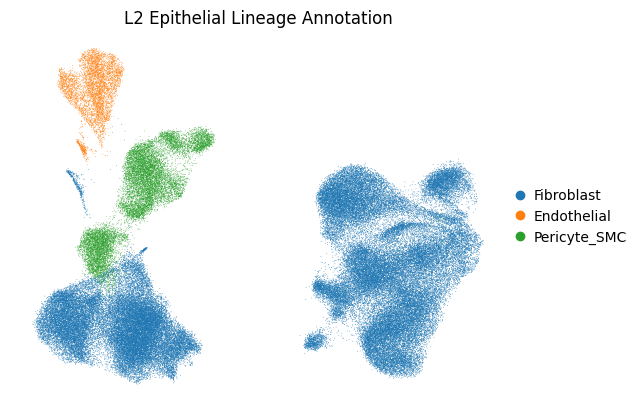

In [14]:
sc.pl.umap(adata,color=["L2_celltype_sub"],frameon=False,title="L2 Epithelial Lineage Annotation",)

## 保存

In [15]:
adata

AnnData object with n_obs × n_vars = 114604 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'GSE_colors', 'L1_lineage_colors', 'L2_celltype_colors', 'REFERENCE_MANU', 'hvg', 'leiden_0.2', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.6', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap', 'L2_celltype_sub_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [16]:
wanted_cols = [
    "GSM", "GSE", "group",
    "L1_lineage",             
    "L2_celltype_sub",        # 最终子类（回收后已含 Other）
]
out_cols = [c for c in wanted_cols if c in adata.obs.columns]

adata.obs[out_cols].to_csv(OUT_CSV, index=True)
print(f"[Saved per-cell table] -> {OUT_CSV}")

[Saved per-cell table] -> /mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data/06_annotation/L3/stromal/L3_stromal_summary.csv


In [17]:
adata.write_h5ad(OUT_H5AD, compression="gzip")
print(f"L1 annotated AnnData saved to: {OUT_H5AD}")
print("Final obs columns:", adata.obs.columns.tolist())

L1 annotated AnnData saved to: /mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data/06_annotation/L3/stromal/L3_stromal_annotated.h5ad
Final obs columns: ['GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub']
